# Exploring Word Representations: From Traditional Word Embeddings to Transformers

### Deep Learning – Self Learning Assignment

**Name:** AJAIKUMAR M  
**Roll No:** 24BAD005  
**Course Code:** 24ADI306  
**Course Outcome:** CO3  
**Bloom's Level:** Apply & Analyze (K3–K4)

---

## Objective

To explore traditional and neural word embedding techniques including
One-Hot Encoding, Bag of Words, TF-IDF, Word2Vec, FastText,
TensorFlow/Keras embeddings, and contextual embeddings using Transformers.

The assignment also focuses on visualizing high-dimensional word embeddings
and identifying semantic relationships between words.

Import libraries

In [ ]:
# Basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Text processing
import re
import string

print("Libraries imported successfully!")

Libraries imported successfully!


Create our sample dataset

In [ ]:
# Sample text dataset

documents = [
    "Deep learning is a powerful branch of artificial intelligence.",
    "Machine learning enables computers to learn from data.",
    "Artificial intelligence uses machine learning and deep learning.",
    "Neural networks are widely used in deep learning applications.",
    "Natural language processing helps computers understand human language.",
    "Transformers are powerful models for natural language processing.",
    "BERT is a transformer model used for language understanding.",
    "Word embeddings represent words as numerical vectors.",
    "Word2Vec learns meaningful relationships between words.",
    "FastText uses subword information to represent words.",
    "TensorFlow and Keras are popular deep learning frameworks.",
    "Python is widely used for machine learning and artificial intelligence.",
    "Data science combines statistics machine learning and programming.",
    "Computer vision and natural language processing are important AI fields.",
    "Deep learning models can solve complex artificial intelligence problems."
]

print("Number of documents:", len(documents))

print("\nSample document:")
print(documents[0])

Number of documents: 15

Sample document:
Deep learning is a powerful branch of artificial intelligence.


Text preprocessing

In [ ]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text

clean_documents = [preprocess_text(doc) for doc in documents]

print("Original:")
print(documents[0])

print("\nAfter preprocessing:")
print(clean_documents[0])

Original:
Deep learning is a powerful branch of artificial intelligence.

After preprocessing:
deep learning is a powerful branch of artificial intelligence


Create word tokens

In [ ]:
tokenized_documents = [doc.split() for doc in clean_documents]

print("Tokens from first document:")
print(tokenized_documents[0])

Tokens from first document:
['deep', 'learning', 'is', 'a', 'powerful', 'branch', 'of', 'artificial', 'intelligence']


## 1. Traditional Text Representation

### 1.1 One-Hot Encoding

One-Hot Encoding represents each word using a binary vector.
Each position in the vector corresponds to a unique word in the vocabulary.

A value of 1 indicates the presence of the word, while all other
positions contain 0.

### Limitation

One-Hot vectors are sparse and do not capture semantic relationships
between words.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Create a small vocabulary from the first document
sample_words = list(dict.fromkeys(tokenized_documents[0]))

# Reshape for OneHotEncoder
words_array = np.array(sample_words).reshape(-1, 1)

# Create encoder
encoder = OneHotEncoder(sparse_output=False)

# Generate one-hot vectors
one_hot_vectors = encoder.fit_transform(words_array)

print("Vocabulary:")
print(sample_words)

print("\nOne-Hot Encoding:")
print(one_hot_vectors)

Vocabulary:
['deep', 'learning', 'is', 'a', 'powerful', 'branch', 'of', 'artificial', 'intelligence']

One-Hot Encoding:
[[0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0.]]


### 1.2 Bag of Words

Bag of Words represents a document using the frequency of words
appearing in the document.

It ignores the order of words and focuses mainly on word occurrence.

### Limitation

Bag of Words produces sparse representations and does not understand
the semantic meaning or context of words.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Create Bag of Words model
bow_vectorizer = CountVectorizer()

# Transform documents
bow_matrix = bow_vectorizer.fit_transform(clean_documents)

# Convert to DataFrame
bow_df = pd.DataFrame(
    bow_matrix.toarray(),
    columns=bow_vectorizer.get_feature_names_out()
)

print("Bag of Words Matrix Shape:", bow_df.shape)

print("\nBag of Words representation:")
display(bow_df.head())

Bag of Words Matrix Shape: (15, 70)

Bag of Words representation:


,ai,and,applications,are,artificial,as,bert,between,branch,can,...,understand,understanding,used,uses,vectors,vision,widely,word,word2vec,words
0,0,0,0,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,1,0,0,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
3,0,0,1,1,0,0,0,0,0,0,...,0,0,1,0,0,0,1,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


### 1.3 TF-IDF

TF-IDF stands for Term Frequency-Inverse Document Frequency.

It assigns higher importance to words that are frequent in a particular
document but less frequent across the entire collection of documents.

TF-IDF is calculated using two main components:

- TF: Term Frequency
- IDF: Inverse Document Frequency

### Advantage

TF-IDF gives more importance to informative words compared with simple
word-frequency representations.

### Limitation

TF-IDF still does not understand the semantic meaning or context of words.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer()

# Transform documents
tfidf_matrix = tfidf_vectorizer.fit_transform(clean_documents)

# Convert to DataFrame
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)

print("TF-IDF Matrix Shape:", tfidf_df.shape)

print("\nTF-IDF representation:")
display(tfidf_df.head())

TF-IDF Matrix Shape: (15, 70)

TF-IDF representation:


,ai,and,applications,are,artificial,as,bert,between,branch,can,...,understand,understanding,used,uses,vectors,vision,widely,word,word2vec,words
0,0.0,0.00000,0.000000,0.000000,0.313617,0.0,0.0,0.0,0.446463,0.0,...,0.000000,0.0,0.0000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0
1,0.0,0.00000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0
2,0.0,0.31734,0.000000,0.000000,0.346549,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0000,0.428386,0.0,0.0,0.000000,0.0,0.0,0.0
3,0.0,0.00000,0.391528,0.275029,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.3034,0.000000,0.0,0.0,0.339976,0.0,0.0,0.0
4,0.0,0.00000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.379904,0.0,0.0000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0


### 1.4 N-Grams

An N-gram is a sequence of N consecutive words.

Examples:

- Unigram → one word
- Bigram → two consecutive words
- Trigram → three consecutive words

N-grams can preserve some local word-order information that
Bag of Words loses.

In [ ]:
# Generate bigrams
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2))

bigram_matrix = bigram_vectorizer.fit_transform(clean_documents)

bigrams = bigram_vectorizer.get_feature_names_out()

print("Sample Bigrams:")
print(bigrams[:20])

Sample Bigrams:
['ai fields' 'and artificial' 'and deep' 'and keras' 'and natural'
 'and programming' 'are important' 'are popular' 'are powerful'
 'are widely' 'artificial intelligence' 'as numerical' 'bert is'
 'between words' 'branch of' 'can solve' 'combines statistics'
 'complex artificial' 'computer vision' 'computers to']


## Comparison of Traditional Text Representation Techniques

| Technique | Representation | Captures Word Frequency | Captures Word Order | Semantic Understanding |
|---|---|---:|---:|---:|
| One-Hot Encoding | Binary vector | No | No | No |
| Bag of Words | Word-count vector | Yes | No | No |
| TF-IDF | Weighted vector | Yes | No | No |
| N-Grams | Sequence/count vector | Yes | Partially | Limited |

### Observation

Traditional text representation techniques are useful for converting
text into numerical form, but they generally do not capture the deeper
semantic relationships between words. This motivates the use of
predictive word embeddings such as Word2Vec.

## 2. Word2Vec – Skip-gram

Word2Vec is a predictive word embedding technique that represents
words as dense numerical vectors.

It learns word representations based on the context in which words
appear in a text corpus.

Word2Vec has two main architectures:

1. Continuous Bag of Words (CBOW)
2. Skip-gram

In CBOW, surrounding context words are used to predict the target word.

In Skip-gram, the target word is used to predict surrounding context words.

In this experiment, the Skip-gram architecture is implemented.

Install/import Gensim

In [ ]:
# Install/update gensim
!pip install -q gensim


from gensim.models import Word2Vec

print("Gensim Word2Vec imported successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 79.0 MB/s eta 0:00:00
Gensim Word2Vec imported successfully!


Prepare the Word2Vec corpus

In [ ]:
# Display the tokenized corpus
print("Number of sentences:", len(tokenized_documents))

print("\nFirst sentence:")
print(tokenized_documents[0])

Number of sentences: 15

First sentence:
['deep', 'learning', 'is', 'a', 'powerful', 'branch', 'of', 'artificial', 'intelligence']


Train the Skip-gram model

In [ ]:
# Train Word2Vec using Skip-gram

word2vec_model = Word2Vec(
    sentences=tokenized_documents,
    vector_size=50,
    window=3,
    min_count=1,
    workers=4,
    sg=1,
    epochs=200,
    seed=42
)

print("Word2Vec Skip-gram model trained successfully!")

Word2Vec Skip-gram model trained successfully!


Check the vocabulary

In [ ]:
# Display vocabulary information

vocabulary = list(word2vec_model.wv.index_to_key)

print("Vocabulary size:", len(vocabulary))

print("\nFirst 20 words:")
print(vocabulary[:20])

Vocabulary size: 71

First 20 words:
['learning', 'language', 'and', 'deep', 'are', 'machine', 'intelligence', 'artificial', 'words', 'for', 'processing', 'natural', 'used', 'is', 'represent', 'models', 'widely', 'uses', 'data', 'to']


Display a word vector

In [ ]:
# Display the vector representation of a word

word = "learning"

vector = word2vec_model.wv[word]

print("Word:", word)
print("Vector size:", len(vector))

print("\nWord vector:")
print(vector)

Word: learning
Vector size: 50

Word vector:
[ 0.05006665 -0.13018097 -0.00843967 -0.02410535  0.09223347  0.06217982
 -0.09545713  0.18473308 -0.0855096  -0.14977038  0.088179    0.27559504
 -0.14221793  0.1666315  -0.02323849  0.05778264  0.14668018 -0.12859274
 -0.19176622  0.00360462 -0.19783406 -0.18697837 -0.11010084  0.05093826
  0.40872222  0.02680262 -0.00928451 -0.02618446 -0.17065474 -0.01320255
  0.0698371  -0.00707385 -0.08813723  0.16192116 -0.12232448 -0.03673256
  0.01213359 -0.5133824  -0.05219334  0.22521308  0.1629923   0.04986364
  0.31741917 -0.12777665  0.06588834  0.05617325  0.0918561   0.4667988
  0.15347789 -0.20520076]


Find similar words

In [ ]:
# Find the 5 most similar words to "learning"

query_word = "learning"

similar_words = word2vec_model.wv.most_similar(
    query_word,
    topn=5
)

print("Query word:", query_word)
print("\nTop 5 similar words:")

for word, similarity in similar_words:
    print(f"{word:20s} {similarity:.4f}")

Query word: learning

Top 5 similar words:
to                   0.9953
deep                 0.9950
are                  0.9948
and                  0.9947
used                 0.9944


Test multiple query words

In [ ]:
def find_similar_words(model, words, topn=5):
    for query_word in words:
        print("=" * 50)
        print("Query word:", query_word)

        if query_word in model.wv:
            results = model.wv.most_similar(query_word, topn=topn)

            for i, (word, score) in enumerate(results, 1):
                print(f"{i}. {word:20s} {score:.4f}")
        else:
            print("Word not found in vocabulary.")


query_words = [
    "learning",
    "artificial",
    "language",
    "computer",
    "words"
]

find_similar_words(word2vec_model, query_words)

Query word: learning
1. to                   0.9953
2. deep                 0.9950
3. are                  0.9948
4. and                  0.9947
5. used                 0.9944
Query word: artificial
1. deep                 0.9937
2. and                  0.9930
3. problems             0.9929
4. can                  0.9928
5. represent            0.9925
Query word: language
1. used                 0.9969
2. are                  0.9959
3. natural              0.9956
4. and                  0.9955
5. deep                 0.9954
Query word: computer
1. processing           0.9938
2. are                  0.9930
3. ai                   0.9928
4. language             0.9924
5. information          0.9918
Query word: words
1. represent            0.9932
2. ai                   0.9931
3. language             0.9929
4. information          0.9927
5. vision               0.9926


Cosine similarity demonstration

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

word1 = "learning"
word2 = "machine"

if word1 in word2vec_model.wv and word2 in word2vec_model.wv:
    vector1 = word2vec_model.wv[word1].reshape(1, -1)
    vector2 = word2vec_model.wv[word2].reshape(1, -1)

    similarity = cosine_similarity(vector1, vector2)[0][0]

    print(f"Cosine similarity between '{word1}' and '{word2}': {similarity:.4f}")

Cosine similarity between 'learning' and 'machine': 0.9932


### Word2Vec Observation

The Word2Vec Skip-gram model converts words into dense numerical
vectors based on their surrounding context.

Words that occur in similar contexts tend to have similar vector
representations. Cosine similarity can therefore be used to identify
words with similar semantic relationships.

The results also show that the quality of learned relationships
depends strongly on the size and diversity of the training corpus.
Since this experiment uses a relatively small sample dataset, the
learned similarities may not always represent strong real-world
semantic relationships.

## 3. FastText Word Embeddings

FastText is a word embedding technique that extends the idea of
Word2Vec by representing words using character-level subword information.

Instead of treating a word as a single indivisible unit, FastText
breaks words into character n-grams.

### Advantages

- Can represent rare words more effectively.
- Can generate representations for previously unseen words.
- Uses subword information to capture similarities between related words.

This makes FastText particularly useful for studying rare and
out-of-vocabulary (OOV) words.

Train the FastText model

In [ ]:
from gensim.models import FastText

# Train FastText model
fasttext_model = FastText(
    sentences=tokenized_documents,
    vector_size=50,
    window=3,
    min_count=1,
    workers=4,
    epochs=200,
    seed=42
)

print("FastText model trained successfully!")

FastText model trained successfully!


Get a FastText word vector

In [ ]:
word = "learning"

vector = fasttext_model.wv[word]

print("Word:", word)
print("Vector size:", len(vector))

print("\nFastText vector:")
print(vector)

Word: learning
Vector size: 50

FastText vector:
[ 0.0254637   0.08671185 -0.02647992 -0.04712108  0.12126196  0.18103737
 -0.01249338  0.00463192 -0.01266664  0.03654599 -0.00452936  0.16467668
 -0.00341862 -0.08402514  0.0165731  -0.00761912 -0.14316188 -0.06388965
  0.03738981 -0.03902926 -0.06961005 -0.02236553  0.06793202 -0.08603781
  0.08642535 -0.1031123  -0.03789332  0.02170137  0.00087906  0.05403271
  0.11679859 -0.01985509 -0.03957029 -0.06795485 -0.0124805  -0.03495126
 -0.02132096 -0.00340153 -0.01043344  0.04249172 -0.06716037  0.03399876
 -0.08913325 -0.02152182  0.069536    0.01071122  0.00724297  0.00425333
  0.06395139  0.03786893]


Find similar words

In [ ]:
query_word = "learning"

similar_words = fasttext_model.wv.most_similar(
    query_word,
    topn=5
)

print("Query word:", query_word)
print("\nTop 5 similar words:")

for word, similarity in similar_words:
    print(f"{word:20s} {similarity:.4f}")

Query word: learning

Top 5 similar words:
learn                0.9990
understanding        0.9988
learns               0.9987
computer             0.9985
relationships        0.9984


Test a rare/OOV word

In [ ]:
oov_word = "learnings"

print("Is the word present in Word2Vec vocabulary?",
      oov_word in word2vec_model.wv)

print("Is the word present in FastText vocabulary?",
      oov_word in fasttext_model.wv)

Is the word present in Word2Vec vocabulary? False
Is the word present in FastText vocabulary? True


In [ ]:
oov_vector = fasttext_model.wv[oov_word]

print("OOV word:", oov_word)
print("Generated vector size:", len(oov_vector))
print("\nGenerated vector:")
print(oov_vector)

OOV word: learnings
Generated vector size: 50

Generated vector:
[ 0.02121928  0.06753953 -0.02059363 -0.03740561  0.09661223  0.14542598
 -0.01154148  0.00356249 -0.00943608  0.02857674 -0.00519802  0.12853163
 -0.00285774 -0.06548629  0.01336166 -0.00504827 -0.11492988 -0.05190085
  0.02898613 -0.0315213  -0.05421374 -0.01832397  0.05580264 -0.06989697
  0.06767353 -0.08179959 -0.03108808  0.01582187  0.0012075   0.04404508
  0.09112506 -0.01328201 -0.03087973 -0.05247501 -0.01283225 -0.02629636
 -0.01744702 -0.00280703 -0.00729136  0.03176605 -0.05255986  0.02801396
 -0.07168914 -0.01738915  0.05451925  0.00637265  0.00713544  0.00408739
  0.05034829  0.02938241]


### OOV Comparison: Word2Vec vs FastText

Word2Vec stores a vector only for words that are present in its
vocabulary. Therefore, it cannot directly provide an embedding for
an unseen word.

FastText uses character-level subword information. As a result,
it can construct an embedding for an unseen or rare word using
the character n-grams contained in that word.

Therefore, FastText generally provides better handling of rare
and out-of-vocabulary words than Word2Vec.

FastText similarity experiment

In [ ]:
test_words = ["learning", "learn", "learner", "learnings"]

for word in test_words:
    vector = fasttext_model.wv[word]
    print(f"{word:15s} -> vector dimension: {len(vector)}")

learning        -> vector dimension: 50
learn           -> vector dimension: 50
learner         -> vector dimension: 50
learnings       -> vector dimension: 50


## Word2Vec vs FastText

| Feature | Word2Vec | FastText |
|---|---|---|
| Word representation | Whole word | Word + character n-grams |
| Dense vectors | Yes | Yes |
| Semantic relationships | Yes | Yes |
| Rare word handling | Limited | Better |
| OOV handling | Poor | Better |
| Subword information | No | Yes |
| Computational requirement | Moderate | Moderate |

### Observation

Both Word2Vec and FastText generate dense word representations.
However, FastText has an important advantage because it uses subword
information. This allows it to construct representations for rare
and previously unseen word forms.

Save the models

In [ ]:
# Save Word2Vec model
word2vec_model.save("word2vec_skipgram.model")

# Save FastText model
fasttext_model.save("fasttext.model")

print("Both models saved successfully!")

Both models saved successfully!


##TensorFlow/Keras Embedding

## 4. Neural Word Embeddings using TensorFlow and Keras

The Keras Embedding layer is a neural network layer that maps
integer-encoded words to dense vectors.

Unlike One-Hot Encoding, which produces sparse vectors, an
Embedding layer learns dense numerical representations.

In this experiment, the words in our text corpus are converted
into integer indices and passed through a Keras Embedding layer.

Import TensorFlow and Keras

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense

print("TensorFlow version:", tf.__version__)
print("TensorFlow and Keras imported successfully!")

TensorFlow version: 2.21.0
TensorFlow and Keras imported successfully!


Convert words into integers

In [ ]:
tokenizer = Tokenizer()

tokenizer.fit_on_texts(clean_documents)

word_index = tokenizer.word_index

print("Vocabulary size:", len(word_index))

print("\nFirst 20 words and their integer IDs:")
print(dict(list(word_index.items())[:20]))

Vocabulary size: 71

First 20 words and their integer IDs:
{'learning': 1, 'deep': 2, 'and': 3, 'language': 4, 'artificial': 5, 'intelligence': 6, 'machine': 7, 'are': 8, 'is': 9, 'used': 10, 'natural': 11, 'processing': 12, 'for': 13, 'words': 14, 'a': 15, 'powerful': 16, 'computers': 17, 'to': 18, 'data': 19, 'uses': 20}


Convert sentences to sequences

In [ ]:
sequences = tokenizer.texts_to_sequences(clean_documents)

print("First document:")
print(clean_documents[0])

print("\nInteger sequence:")
print(sequences[0])

First document:
deep learning is a powerful branch of artificial intelligence

Integer sequence:
[2, 1, 9, 15, 16, 24, 25, 5, 6]


Padding

In [ ]:
padded_sequences = pad_sequences(
    sequences,
    padding="post"
)

print("Original number of documents:", len(sequences))
print("Padded sequence shape:", padded_sequences.shape)

print("\nFirst padded sequence:")
print(padded_sequences[0])

Original number of documents: 15
Padded sequence shape: (15, 10)

First padded sequence:
[ 2  1  9 15 16 24 25  5  6  0]


Create the Keras Embedding model

In [ ]:
from tensorflow.keras import Input

vocab_size = len(word_index) + 1
embedding_dim = 50
max_length = padded_sequences.shape[1]

keras_model = Sequential([
    Input(shape=(max_length,)),
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim
    ),
    GlobalAveragePooling1D(),
    Dense(1, activation="sigmoid")
])

keras_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

keras_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 10, 50)         │         3,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 50)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,651 (14.26 KB)

 Trainable params: 3,651 (14.26 KB)

 Non-trainable params: 0 (0.00 B)

Extract the learned embedding matrix

In [ ]:
# Extract the embedding matrix

embedding_matrix = keras_model.layers[0].get_weights()[0]

print("Embedding matrix shape:")
print(embedding_matrix.shape)

Embedding matrix shape:
(72, 50)


Display one word's Keras embedding

In [ ]:
word = "learning"

word_id = word_index[word]

word_vector = embedding_matrix[word_id]

print("Word:", word)
print("Word ID:", word_id)
print("Embedding dimension:", len(word_vector))

print("\nEmbedding vector:")
print(word_vector)

Word: learning
Word ID: 1
Embedding dimension: 50

Embedding vector:
[ 0.03515473  0.00497323  0.04105966  0.01218048  0.01274082 -0.01818625
 -0.03201137 -0.01046717  0.03241222  0.03525443 -0.02318773  0.02291048
 -0.00943734 -0.02992896  0.04198    -0.00086764 -0.01401366 -0.02333353
 -0.03257027 -0.00705879 -0.02520323  0.02051356  0.03585655 -0.01485754
  0.04869279  0.0490019   0.0149626  -0.01904656  0.03318008 -0.01074699
 -0.04495909  0.03067421 -0.04461391  0.0429295   0.00506824 -0.0215979
  0.00169164 -0.02746911  0.00642835  0.03944473  0.00739624 -0.00317146
  0.02421503  0.00779657  0.03490416 -0.01908324  0.00896166  0.03417393
  0.01685932 -0.00599959]


### Keras Embedding Observation

The Keras Embedding layer converts integer-encoded words into dense
vectors of fixed dimension.

In this experiment, each word is represented using a 50-dimensional
vector. Unlike One-Hot Encoding, these representations are dense
and can be learned as part of a neural network.

The embedding vectors can be used as input representations for
downstream neural network tasks.

##BERT introduction

## 5. Transformer-Based NLP – BERT

BERT (Bidirectional Encoder Representations from Transformers) is a
pretrained Transformer-based language model.

Unlike traditional static word embeddings, BERT generates contextual
representations. The representation of a word can change depending
on the surrounding words.

For example, the word "bank" has different meanings in:

1. I went to the bank to deposit money.
2. I sat near the bank of the river.

BERT can use the surrounding context to produce different
representations for the word "bank".

Install Transformers

In [ ]:
!pip install -q transformers

In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch

print("Transformers imported successfully!")
print("PyTorch version:", torch.__version__)

Transformers imported successfully!
PyTorch version: 2.11.0+cu130


Load pretrained BERT

In [ ]:
model_name = "google-bert/bert-base-uncased"

tokenizer_bert = AutoTokenizer.from_pretrained(
    model_name,
    use_fast=False
)

bert_model = AutoModel.from_pretrained(model_name)

print("BERT model loaded successfully!")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT model loaded successfully!


Create two sentences

In [ ]:
sentence1 = "I went to the bank to deposit money."
sentence2 = "I sat near the bank of the river."

print(sentence1)
print(sentence2)

I went to the bank to deposit money.
I sat near the bank of the river.


Tokenize both sentences

In [ ]:
inputs1 = tokenizer_bert(
    sentence1,
    return_tensors="pt"
)

inputs2 = tokenizer_bert(
    sentence2,
    return_tensors="pt"
)

tokens1 = tokenizer_bert.convert_ids_to_tokens(inputs1["input_ids"][0])
tokens2 = tokenizer_bert.convert_ids_to_tokens(inputs2["input_ids"][0])

print("Sentence 1 tokens:")
print(tokens1)

print("\nSentence 2 tokens:")
print(tokens2)

Sentence 1 tokens:
['[CLS]', 'i', 'went', 'to', 'the', 'bank', 'to', 'deposit', 'money', '.', '[SEP]']

Sentence 2 tokens:
['[CLS]', 'i', 'sat', 'near', 'the', 'bank', 'of', 'the', 'river', '.', '[SEP]']


Generate BERT embeddings

In [ ]:
with torch.no_grad():
    outputs1 = bert_model(**inputs1)
    outputs2 = bert_model(**inputs2)

embeddings1 = outputs1.last_hidden_state
embeddings2 = outputs2.last_hidden_state

print("Sentence 1 embedding shape:", embeddings1.shape)
print("Sentence 2 embedding shape:", embeddings2.shape)

Sentence 1 embedding shape: torch.Size([1, 11, 768])
Sentence 2 embedding shape: torch.Size([1, 11, 768])


Find the position of "bank"

In [ ]:
bank_position1 = tokens1.index("bank")
bank_position2 = tokens2.index("bank")

print("Bank position in Sentence 1:", bank_position1)
print("Bank position in Sentence 2:", bank_position2)

Bank position in Sentence 1: 5
Bank position in Sentence 2: 5


Extract the BERT embedding for "bank"

In [ ]:
bank_embedding1 = embeddings1[0, bank_position1].numpy()
bank_embedding2 = embeddings2[0, bank_position2].numpy()

print("Sentence 1 - bank embedding shape:", bank_embedding1.shape)
print("Sentence 2 - bank embedding shape:", bank_embedding2.shape)

print("\nFirst 10 values of Sentence 1 bank embedding:")
print(bank_embedding1[:10])

print("\nFirst 10 values of Sentence 2 bank embedding:")
print(bank_embedding2[:10])

Sentence 1 - bank embedding shape: (768,)
Sentence 2 - bank embedding shape: (768,)

First 10 values of Sentence 1 bank embedding:
[ 0.7091018  -0.25904217 -0.01858974 -0.09361473  1.2636592   0.02228601
 -0.3096254   0.9713599  -0.10284817  0.20124632]

First 10 values of Sentence 2 bank embedding:
[-0.16249432 -0.5112546  -0.22568835 -0.00979034 -0.57436734 -0.07770481
  0.11227506  1.9981805   0.09553193 -0.4773217 ]


Compare the two "bank" embeddings

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(
    [bank_embedding1],
    [bank_embedding2]
)[0][0]

print("Cosine similarity between the two 'bank' embeddings:", similarity)

Cosine similarity between the two 'bank' embeddings: 0.532584


### Step 48: BERT Contextual Representation - Observation

BERT generates contextual word embeddings, meaning that the representation of a word depends on the surrounding words in the sentence.

In this experiment, the word "bank" was used in two different contexts:

1. "I went to the bank to deposit money." - financial context
2. "I sat near the bank of the river." - geographical context

Although the word "bank" is the same in both sentences, BERT produces different 768-dimensional embeddings for the word based on its context.

The cosine similarity between the two embeddings was calculated to compare their representations. This demonstrates that BERT can capture contextual meaning, unlike traditional static word embeddings such as Word2Vec and GloVe, where a word generally has one fixed vector.

Visualize Word2Vec embeddings using PCA

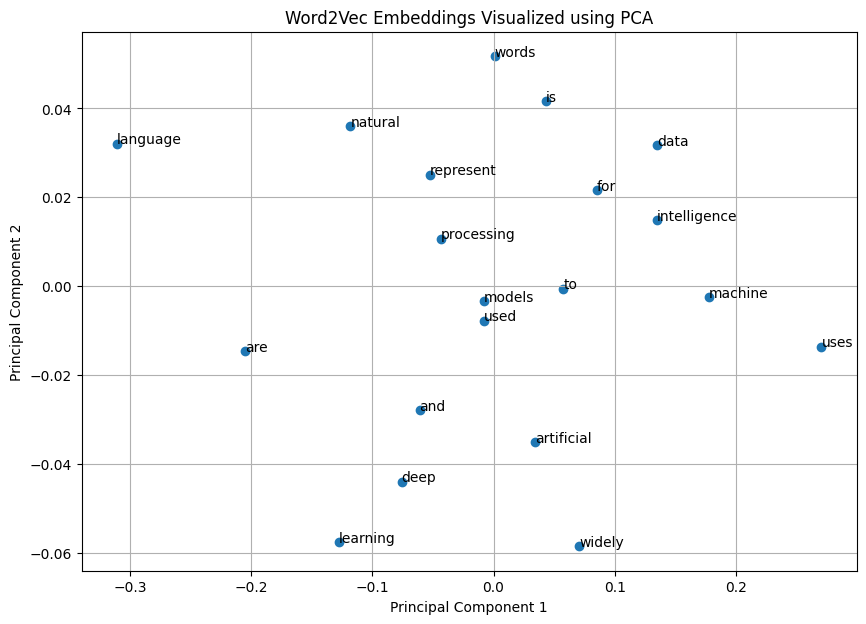

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Select words from the Word2Vec vocabulary
words = list(word2vec_model.wv.index_to_key)[:20]

# Get their vectors
vectors = [word2vec_model.wv[word] for word in words]

# Reduce 50 dimensions to 2 dimensions
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors)

# Plot
plt.figure(figsize=(10, 7))

plt.scatter(
    vectors_2d[:, 0],
    vectors_2d[:, 1]
)

for i, word in enumerate(words):
    plt.annotate(
        word,
        (vectors_2d[i, 0], vectors_2d[i, 1])
    )

plt.title("Word2Vec Embeddings Visualized using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

Visualize FastText embeddings using PCA

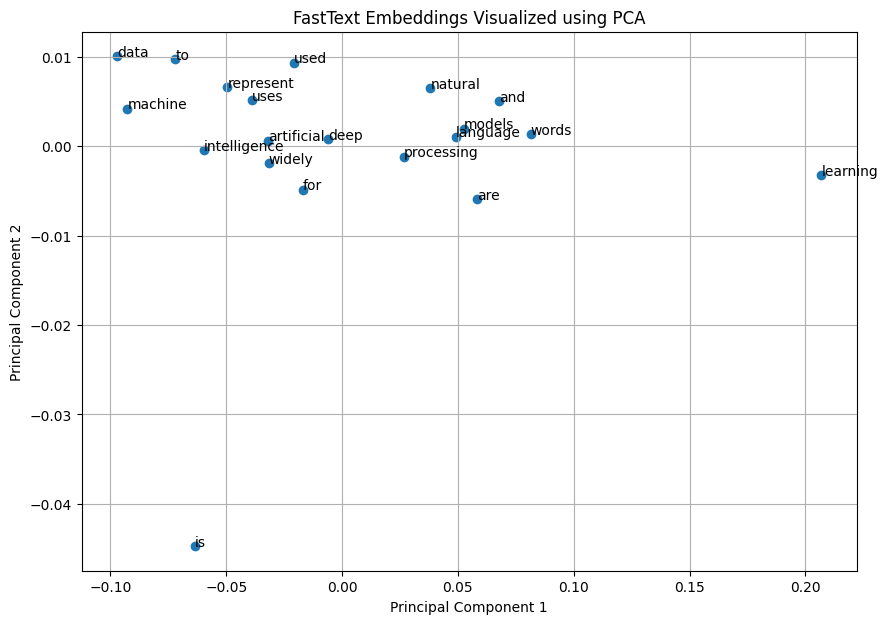

In [48]:
# Select words from the FastText vocabulary
words_ft = list(fasttext_model.wv.index_to_key)[:20]

# Get FastText vectors
vectors_ft = [fasttext_model.wv[word] for word in words_ft]

# Reduce 50 dimensions to 2 dimensions
pca_ft = PCA(n_components=2)
vectors_ft_2d = pca_ft.fit_transform(vectors_ft)

# Plot
plt.figure(figsize=(10, 7))

plt.scatter(
    vectors_ft_2d[:, 0],
    vectors_ft_2d[:, 1]
)

for i, word in enumerate(words_ft):
    plt.annotate(
        word,
        (vectors_ft_2d[i, 0], vectors_ft_2d[i, 1])
    )

plt.title("FastText Embeddings Visualized using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

Visualize Keras Embeddings using PCA

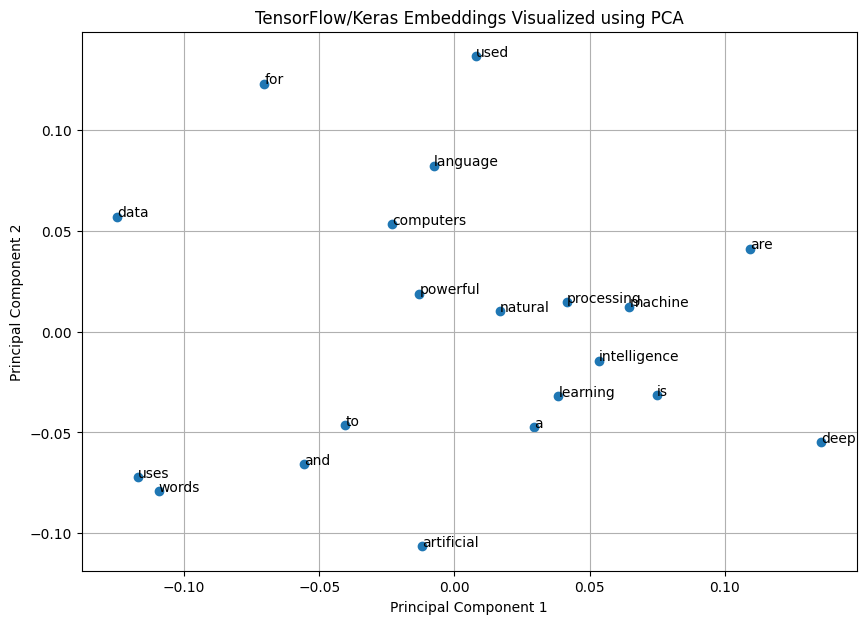

In [49]:
# Get words and their Keras embedding vectors
keras_words = list(word_index.keys())[:20]

keras_vectors = []

for word in keras_words:
    index = word_index[word]
    keras_vectors.append(embedding_matrix[index])

# Convert to array
keras_vectors = np.array(keras_vectors)

# Reduce dimensions to 2D
pca_keras = PCA(n_components=2)
keras_vectors_2d = pca_keras.fit_transform(keras_vectors)

# Plot
plt.figure(figsize=(10, 7))

plt.scatter(
    keras_vectors_2d[:, 0],
    keras_vectors_2d[:, 1]
)

for i, word in enumerate(keras_words):
    plt.annotate(
        word,
        (keras_vectors_2d[i, 0], keras_vectors_2d[i, 1])
    )

plt.title("TensorFlow/Keras Embeddings Visualized using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

Create a BERT embedding visualization

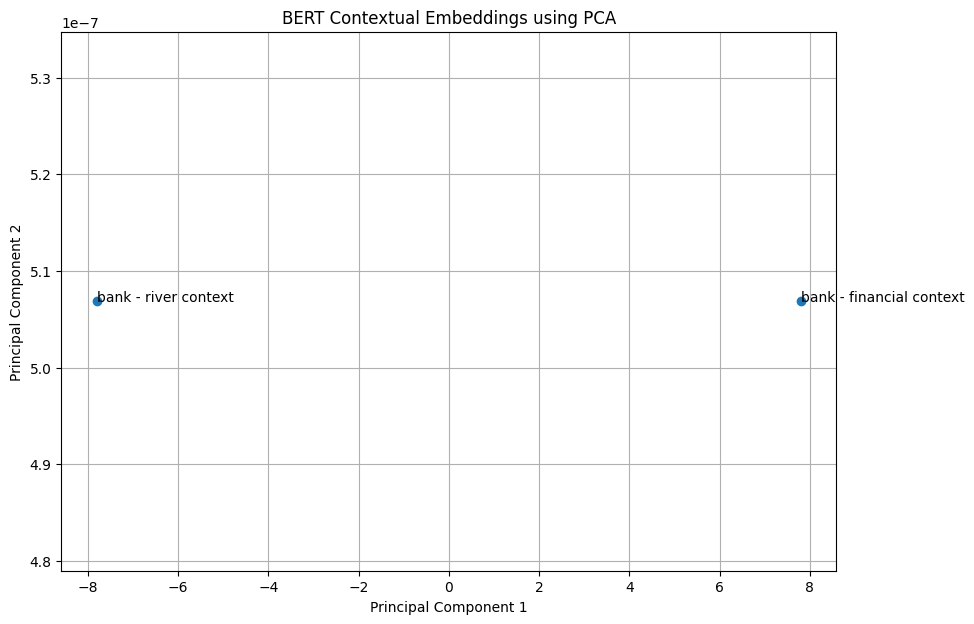

In [50]:
# Combine the two BERT "bank" embeddings
bert_vectors = np.array([
    bank_embedding1,
    bank_embedding2
])

bert_labels = [
    "bank - financial context",
    "bank - river context"
]

# Reduce 768 dimensions to 2 dimensions
pca_bert = PCA(n_components=2)
bert_vectors_2d = pca_bert.fit_transform(bert_vectors)

# Plot
plt.figure(figsize=(10, 7))

plt.scatter(
    bert_vectors_2d[:, 0],
    bert_vectors_2d[:, 1]
)

for i, label in enumerate(bert_labels):
    plt.annotate(
        label,
        (bert_vectors_2d[i, 0], bert_vectors_2d[i, 1])
    )

plt.title("BERT Contextual Embeddings using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

##Comparison of Word Representation Techniques

| Technique | Type | Contextual? | OOV Handling | Main Advantage | Main Limitation |
|---|---|---|---|---|---|
| One-Hot Encoding | Traditional | No | Poor | Simple and easy to implement | Very high-dimensional and sparse |
| TF-IDF | Frequency-based | No | Poor | Represents word importance in documents | Does not capture deep semantic meaning |
| Word2Vec | Predictive | No | Poor | Captures semantic relationships between words | Unknown words cannot be represented directly |
| FastText | Subword-based | No | Good | Handles rare and unseen words using subword information | More computationally expensive than Word2Vec |
| Keras Embedding | Neural | No | Limited | Learnable dense word representations | Requires training data and optimization |
| BERT | Transformer-based | Yes | Better than static embeddings | Captures meaning based on sentence context | Computationally expensive |

### Overall Observation

Traditional methods such as One-Hot and TF-IDF are simple and useful for basic text representation, but they do not capture contextual meaning effectively.

Word2Vec produces dense semantic representations and can capture relationships between words. FastText improves upon Word2Vec by using subword information, making it more suitable for rare and unseen words.

The TensorFlow/Keras Embedding layer provides trainable dense representations that can be learned as part of a neural network.

BERT provides contextual representations. In the experiment, the same word "bank" received different embeddings when used in a financial context and a river context. This demonstrates the advantage of contextual embeddings over static word representations.

##Overall Analysis

The experiments demonstrate the progression from traditional word representation methods to modern contextual embeddings.

One-Hot, Bag of Words and TF-IDF represent text using word occurrence or importance, but they do not capture contextual meaning effectively. Word2Vec learns dense semantic relationships from surrounding words, while FastText additionally uses subword information and can therefore represent rare or unseen words more effectively.

The TensorFlow/Keras Embedding layer provides learnable dense vectors that can be integrated into neural network models. BERT provides a more advanced contextual representation in which the same word can have different embeddings depending on its surrounding words.

The PCA visualizations helped reduce high-dimensional embeddings into two dimensions for visual comparison. Overall, contextual Transformer-based embeddings provide richer representations of word meaning, while traditional and static embeddings remain simpler and computationally less demanding.

Experimental Results Summary

In [51]:
# Calculate final BERT contextual similarity
bert_similarity = cosine_similarity(
    [bank_embedding1],
    [bank_embedding2]
)[0][0]

# FastText OOV test
oov_word = "learnings"
oov_vector = fasttext_model.wv[oov_word]

# Display results
print("========== EXPERIMENTAL RESULTS ==========")

print("\n1. Word2Vec Vocabulary Size:")
print(len(word2vec_model.wv.index_to_key))

print("\n2. FastText Vocabulary Size:")
print(len(fasttext_model.wv.index_to_key))

print("\n3. FastText OOV Test:")
print("Word:", oov_word)
print("Vector Dimension:", oov_vector.shape)
print("OOV vector successfully generated: Yes")

print("\n4. BERT Contextual Representation:")
print("Financial context: bank")
print("River context: bank")
print("Cosine Similarity:", bert_similarity)

print("\n5. BERT Embedding Dimension:")
print(bank_embedding1.shape[0])

print("\n========== END OF RESULTS ==========")

========== EXPERIMENTAL RESULTS ==========

1. Word2Vec Vocabulary Size:
71

2. FastText Vocabulary Size:
71

3. FastText OOV Test:
Word: learnings
Vector Dimension: (50,)
OOV vector successfully generated: Yes

4. BERT Contextual Representation:
Financial context: bank
River context: bank
Cosine Similarity: 0.532584

5. BERT Embedding Dimension:
768

========== END OF RESULTS ==========


##Conclusion

This assignment explored different approaches for representing words and text, starting from traditional techniques such as One-Hot Encoding, Bag of Words, TF-IDF and N-grams, and progressing to modern neural and Transformer-based representations.

Word2Vec was implemented using the Skip-gram architecture to learn dense word representations from surrounding context. FastText was also implemented and tested with a previously unseen word, "learnings". FastText successfully generated a 50-dimensional vector for the OOV word by using subword information.

A TensorFlow/Keras Embedding layer was used to generate trainable dense word representations. BERT was then used to demonstrate contextual word embeddings. The word "bank" was tested in two different contexts: a financial context and a river context. The resulting embeddings were different, with a cosine similarity of approximately 0.533, demonstrating that BERT represents words according to their surrounding context.

PCA was used to visualize Word2Vec, FastText, TensorFlow/Keras and BERT embeddings in two dimensions. These visualizations provided a graphical representation of the high-dimensional embedding spaces.

Overall, the experiments show the progression from sparse traditional representations to dense static embeddings and finally to contextual Transformer-based representations. Traditional methods are simple and computationally efficient, Word2Vec captures semantic relationships, FastText provides better handling of rare and unseen words, and BERT provides context-dependent representations.